# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from automate_Risma import preprocess_data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

The "Adult Dataset Income" contains demographic and employment information, including age, work class, education, marital status, occupation, race, gender, hours worked per week, and native country.

https://www.kaggle.com/datasets/rabailanees/adult-income-dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/rismaamaliyah/Eksperimen_SML_RIsma/refs/heads/main/adult_income_dataset_raw.csv")
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32560 non-null  int64 
 1   workclass       32560 non-null  object
 2   fnlwgt          32560 non-null  int64 
 3   education       32560 non-null  object
 4   education_num   32560 non-null  int64 
 5   marital_status  32560 non-null  object
 6   occupation      32560 non-null  object
 7   relationship    32560 non-null  object
 8   race            32560 non-null  object
 9   sex             32560 non-null  object
 10  capital_gain    32560 non-null  int64 
 11  capital_loss    32560 non-null  int64 
 12  hours_per_week  32560 non-null  int64 
 13  native_country  32560 non-null  object
 14  income          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
# Strip spaces from all object columns before replacing '?'
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Re-apply replacement of '?' with np.nan
df.replace('?', np.nan, inplace=True)

# Check null values again
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [6]:
df.duplicated().sum()

np.int64(24)

In [7]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1297
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [9]:
df['education'].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5354
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


In [10]:
df['income'].value_counts()

,count
income,
<=50K,24719
>50K,7841


In [11]:
df['income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.759183
>50K,0.240817


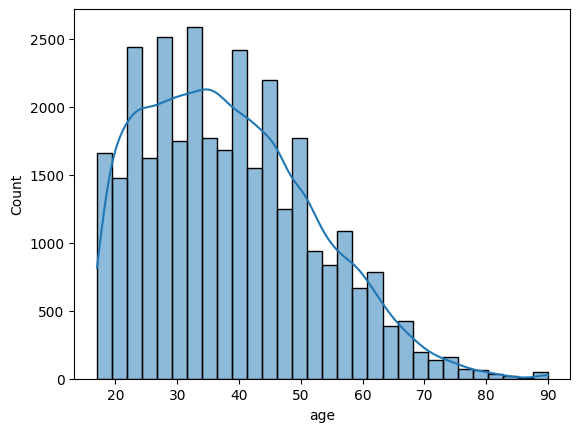

In [12]:
sns.histplot(df['age'], bins=30, kde=True)
plt.show()

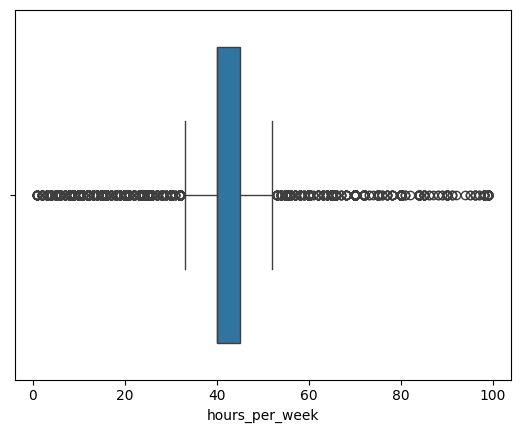

In [13]:
sns.boxplot(x=df['hours_per_week'])
plt.show()

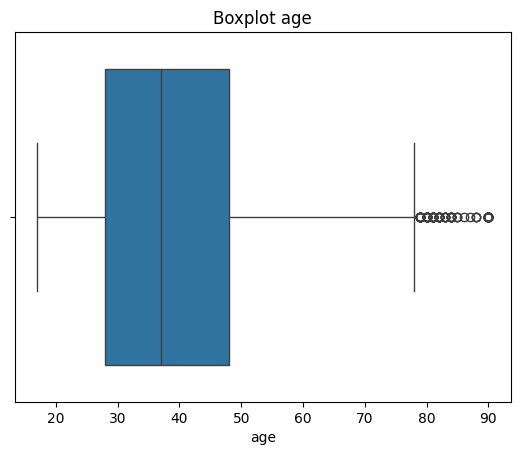

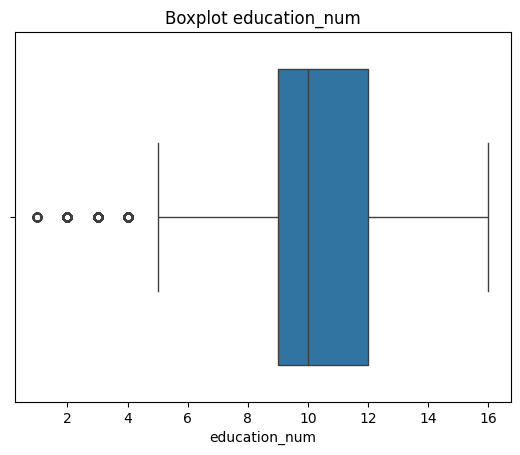

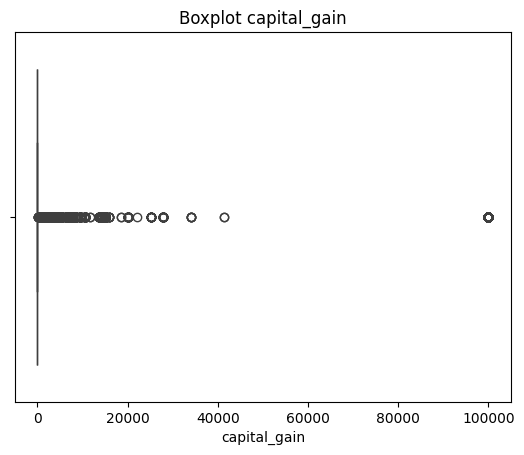

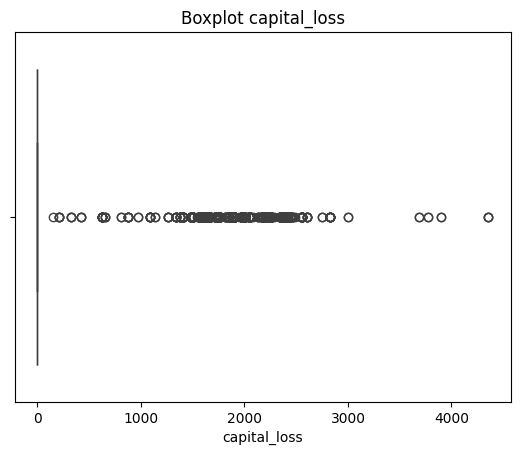

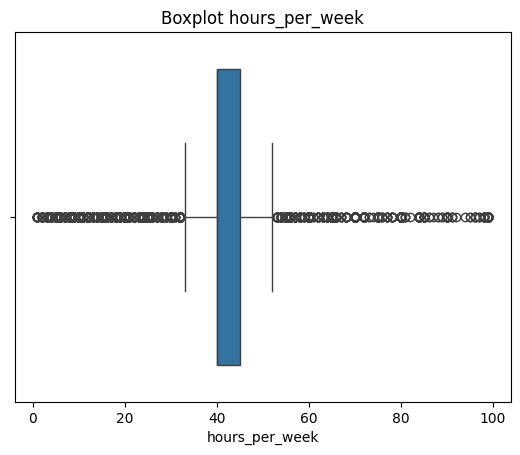

In [14]:
for col in ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']:
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot {col}")
  plt.show()

In [15]:
for col in ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"Lower bound {col}:", lower_bound)
        print(f"Upper bound {col}:", upper_bound)

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Number of outliers in {col}:", len(outliers))

Lower bound age: -2.0
Upper bound age: 78.0
Number of outliers in age: 143
Lower bound education_num: 4.5
Upper bound education_num: 16.5
Number of outliers in education_num: 1198
Lower bound capital_gain: 0.0
Upper bound capital_gain: 0.0
Number of outliers in capital_gain: 2711
Lower bound capital_loss: 0.0
Upper bound capital_loss: 0.0
Number of outliers in capital_loss: 1519
Lower bound hours_per_week: 32.5
Upper bound hours_per_week: 52.5
Number of outliers in hours_per_week: 9008


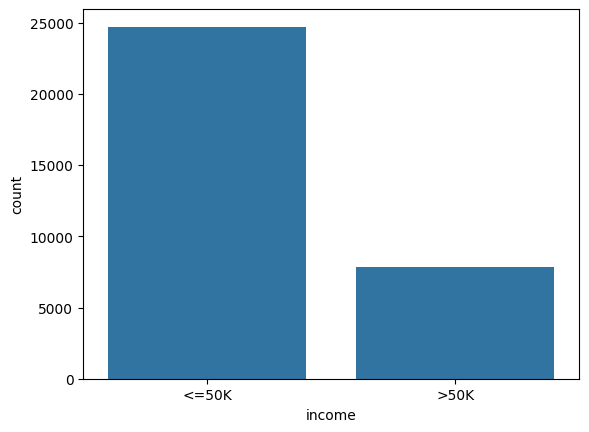

In [16]:
sns.countplot(x='income', data=df)
plt.show()

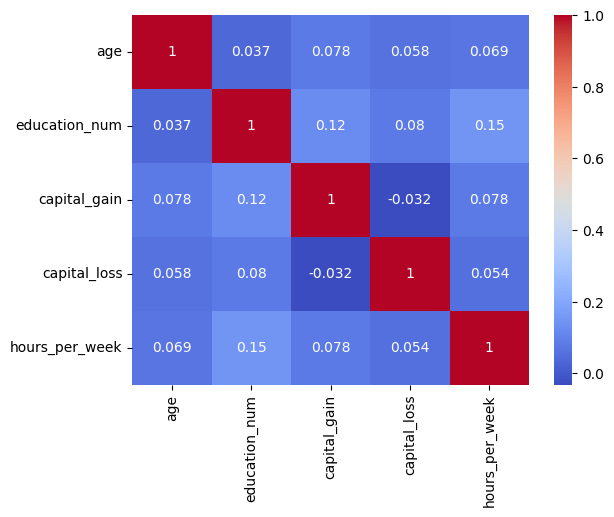

In [17]:
corr = df[['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
X, y, data_preprocessor = preprocess_data(df)

print("Shape of X (features before encoding/scaling):", X.shape)
print("Shape of y (target variable):", y.shape)
print("Value counts for y:")
print(y.value_counts())

Shape of X (features before encoding/scaling): (32536, 13)
Shape of y (target variable): (32536,)
Value counts for y:
income
0    24697
1     7839
Name: count, dtype: int64


/content/automate_Risma.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [19]:
clf = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [22]:
print("Train score:", clf.score(X_train, y_train))
print("Test score:", clf.score(X_test, y_test))

Train score: 0.9664207776240972
Test score: 0.8173017824216349


In [23]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4961
           1       0.63      0.57      0.60      1547

    accuracy                           0.82      6508
   macro avg       0.75      0.73      0.74      6508
weighted avg       0.81      0.82      0.81      6508



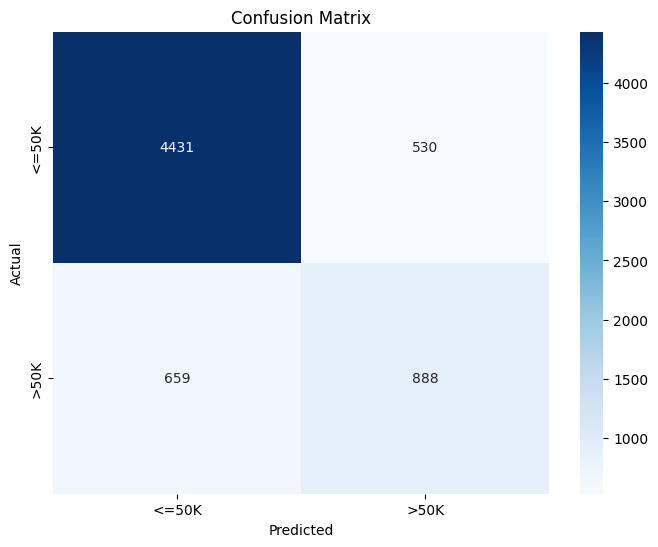

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
X_train_processed = data_preprocessor.fit_transform(X_train)
X_test_processed = data_preprocessor.transform(X_test)

num_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
cat_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
ohe = data_preprocessor.named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(cat_features)
all_features = np.concatenate([num_features, ohe_features])

X_train_df = pd.DataFrame(X_train_processed.toarray(), columns=all_features)
X_test_df = pd.DataFrame(X_test_processed.toarray(), columns=all_features)

train_preprocessed_df = pd.concat([X_train_df, y_train.reset_index(drop=True)], axis=1)
test_preprocessed_df = pd.concat([X_test_df, y_test.reset_index(drop=True)], axis=1)

train_preprocessed_df.to_csv("adult_income_dataset_preprocessing.csv", index=False)
test_preprocessed_df.to_csv("adult_income_dataset_preprocessing_test.csv", index=False)